# Predicting Student Health Risk
**Kaggle Playground Series S6E7**: classify each student's `health_condition` as `at-risk`, `fit` or `unhealthy`.

- **Metric:** balanced accuracy, the mean of the three per-class recalls. 86% of students are `at-risk`, so a model
  that always predicts the majority class scores 0.86 accuracy but only 0.333 balanced accuracy.
- **Data:** 690k training and 296k test rows with 7 numeric and 6 categorical lifestyle features, every one with
  1-12% missing values. Generated synthetically from the
  [College Student Health Behavior Dataset](https://www.kaggle.com/datasets/ziya07/college-student-health-behavior-dataset)
  (50k rows, called the *original* dataset below).
- **Approach**, taken from the winning write-ups and the strongest public notebooks:
  1. the decision rule is the biggest lever: predict `argmax(p / class prior)` instead of `argmax(p)` (+0.06 balanced
     accuracy in every top write-up);
  2. the original labels follow a simple points rule on sleep, stress and activity, so the rule score and its bounds
     under missing values become features;
  3. exact-value target encoding of every column (the generator reuses a finite set of values), fitted inside each fold;
  4. XGBoost and LightGBM on the same 5 folds, probability blend, class multipliers tuned on out-of-fold predictions.

The competition closed on 31 July 2026. The submission at the end is a late submission, which Kaggle still
scores on both the public and private leaderboards.

In [1]:
import io, subprocess, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)

COMP = 'playground-series-s6e7'
SEED = 42
N_FOLDS = 5
TARGET = 'health_condition'
CLASSES = np.array(['at-risk', 'fit', 'unhealthy'])

# Plot styling: one fixed colour per class, recessive grid
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
CLASS_COLOR = dict(zip(CLASSES, [BLUE, ORANGE, AQUA]))
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e5e1', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.edgecolor': '#9a9994', 'axes.titleweight': 'bold', 'axes.titlesize': 11, 'font.size': 9,
    'lines.linewidth': 2,
})

## 1. Load data

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')

# Original dataset, used here only to understand how the labels were made. Download with:
#   kaggle datasets download ziya07/college-student-health-behavior-dataset -p original --unzip
orig = pd.read_csv('original/student_health_dataset_50k.csv')
print('train', train.shape, '| test', test.shape, '| original', orig.shape)
train.head()

train (690088, 15) | test (295753, 14) | original (50000, 16)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## 2. EDA
### 2.1 Structure, missing values and class balance

In [3]:
NUMS = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
CATS = ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
FEATURES = NUMS + CATS

summary = pd.DataFrame({
    'dtype': train[FEATURES].dtypes.astype(str),
    'n_unique': train[FEATURES].nunique(),
    'train_missing_%': (train[FEATURES].isna().mean() * 100).round(2),
    'test_missing_%': (test[FEATURES].isna().mean() * 100).round(2),
})
display(summary)
prior = train[TARGET].value_counts(normalize=True).reindex(CLASSES)
display(pd.DataFrame({'train': prior, 'original': orig[TARGET].value_counts(normalize=True).reindex(CLASSES)}).round(4))
print(f'Rows with at least one missing value: {train[FEATURES].isna().any(axis=1).mean():.1%}')

,dtype,n_unique,train_missing_%,test_missing_%
sleep_duration,float64,701,11.01,11.01
heart_rate,float64,537,1.14,1.14
bmi,float64,1596,2.01,2.01
calorie_expenditure,float64,2101,7.66,7.66
step_count,float64,12807,2.02,2.02
exercise_duration,float64,856,1.00,1.00
water_intake,float64,400,6.30,6.30
diet_type,str,3,1.00,1.00
stress_level,str,3,12.00,12.00
sleep_quality,str,3,8.45,8.45


,train,original
health_condition,,
at-risk,0.8587,0.8744
fit,0.0577,0.0493
unhealthy,0.0836,0.0763


Rows with at least one missing value: 49.3%


### 2.2 How the labels were made
A community post found that the original labels follow a points rule on three columns: 2 points for sleeping under
6 hours, 1 point for medium stress and 3 for high stress, 1 point for moderate or sedentary activity. Zero points
means `fit`, 1-4 `at-risk`, 5-6 `unhealthy`. Checking it on the original data and on the synthetic training rows
where all three inputs are present:

In [4]:
STRESS_PTS = {'low': 0, 'medium': 1, 'high': 3}
ACTIVITY_PTS = {'active': 0, 'moderate': 1, 'sedentary': 1}

def rule_points(df):
    sleep = np.where(df['sleep_duration'].isna(), np.nan, (df['sleep_duration'] < 6) * 2.0)
    return sleep + df['stress_level'].map(STRESS_PTS).astype(float) + df['physical_activity_level'].map(ACTIVITY_PTS).astype(float)

def rule_label(points):
    return pd.cut(points, [-np.inf, 0, 4, np.inf], labels=['fit', 'at-risk', 'unhealthy']).astype(str)

pts_orig, pts_train = rule_points(orig), pd.Series(rule_points(train))
known = pts_train.notna()
print(f'Rule balanced accuracy, original: {balanced_accuracy_score(orig[TARGET], rule_label(pts_orig)):.4f}')
print(f'Rule balanced accuracy, synthetic rows with all 3 inputs ({known.mean():.0%} of train): '
      f'{balanced_accuracy_score(train.loc[known, TARGET], rule_label(pts_train[known])):.4f}')
display(pd.crosstab(pts_train[known].astype(int).rename('rule points'), train.loc[known, TARGET])[CLASSES])

Rule balanced accuracy, original: 0.9906


Rule balanced accuracy, synthetic rows with all 3 inputs (74% of train): 0.9604


health_condition,at-risk,fit,unhealthy
rule points,,,
0,12184,28163,103
1,130268,417,356
2,127283,355,353
3,64983,202,379
4,104018,309,625
5,137,47,13674
6,362,78,27379


### 2.3 The three rule inputs by class

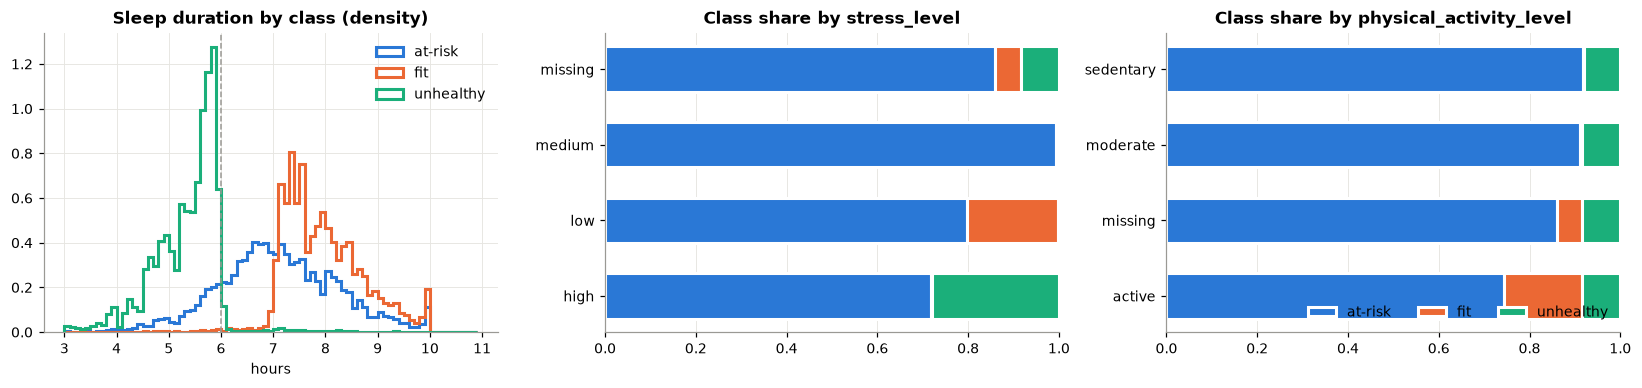

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for cls in CLASSES:
    s = train.loc[train[TARGET] == cls, 'sleep_duration'].dropna()
    axes[0].hist(s, bins=np.arange(3, 11, 0.1), histtype='step', linewidth=2, density=True, color=CLASS_COLOR[cls], label=cls)
axes[0].axvline(6, color='#9a9994', ls='--', lw=1)
axes[0].set_title('Sleep duration by class (density)'); axes[0].set_xlabel('hours'); axes[0].legend(frameon=False)
for ax, col in zip(axes[1:], ['stress_level', 'physical_activity_level']):
    share = pd.crosstab(train[col].fillna('missing'), train[TARGET], normalize='index')[CLASSES]
    left = np.zeros(len(share))
    for cls in CLASSES:
        ax.barh(share.index, share[cls], left=left, color=CLASS_COLOR[cls], label=cls, height=0.6,
                edgecolor='white', linewidth=2)
        left += share[cls].values
    ax.set_title(f'Class share by {col}'); ax.set_xlim(0, 1)
axes[2].legend(frameon=False, ncol=3, loc='lower right')
plt.tight_layout(); plt.show()

**EDA takeaways**
- Every feature has missing values (26% of rows miss at least one of the three rule inputs). Missingness is the
  main source of error, so NaNs are kept as-is: trees route them natively and the rule bounds below quantify them.
- Where all three inputs are present, the points rule alone scores about 0.96 balanced accuracy. Its one ambiguous
  cell is 0 points, where about 30% of students are labelled `at-risk` instead of `fit` (the original data has the
  same quirk), which caps the achievable score near 0.95.
- The minority classes are tiny (5.8% `fit`, 8.4% `unhealthy`), so the decision rule must be tuned for balanced accuracy.

## 3. Feature engineering
- **Rule features:** the points from each input, the total, and its lower and upper bounds when inputs are missing
  (missing sleep could be 0 or 2 points, missing stress 0-3, missing activity 0-1). The bounds often pin the class
  down even when the total is unknown.
- **Distance to the sleep threshold** (`sleep_duration - 6`), so trees need no fine binning near 6 hours.
- **Exact-value target encoding** of all 13 columns (fold-safe, added in the CV loop), plus value counts: the
  synthetic generator reuses a finite set of values, so a value's identity carries signal.
- Categoricals stay native (`category` dtype with NaN), numerics keep their NaNs.

In [6]:
def make_features(df):
    out = df[FEATURES].copy()
    sleep_pts = np.where(df['sleep_duration'].isna(), np.nan, (df['sleep_duration'] < 6) * 2.0)
    stress_pts = df['stress_level'].map(STRESS_PTS).astype(float).values
    act_pts = df['physical_activity_level'].map(ACTIVITY_PTS).astype(float).values
    parts = np.column_stack([sleep_pts, stress_pts, act_pts])
    out['sleep_pts'], out['stress_pts'], out['activity_pts'] = sleep_pts, stress_pts, act_pts
    out['rule_points'] = parts.sum(1)                                     # NaN when any input is missing
    out['rule_min'] = np.nan_to_num(parts, nan=0).sum(1)
    out['rule_max'] = np.where(np.isnan(parts), [2, 3, 1], parts).sum(1)
    out['rule_n_missing'] = np.isnan(parts).sum(1)
    out['sleep_minus_6'] = df['sleep_duration'] - 6
    out['n_missing'] = df[FEATURES].isna().sum(axis=1)
    return out

full = pd.concat([make_features(train), make_features(test)], ignore_index=True)
for c in NUMS:
    full[f'cnt_{c}'] = full[c].map(full[c].value_counts()).astype('float32')
for c in CATS:
    full[c] = full[c].astype('category')

n_tr = len(train)
X = full.iloc[:n_tr].reset_index(drop=True)
X_test = full.iloc[n_tr:].reset_index(drop=True)
class_to_int = {c: i for i, c in enumerate(CLASSES)}
y = train[TARGET].map(class_to_int).values
PRIOR = np.bincount(y) / len(y)
del full
print('features:', X.shape[1], '| train', X.shape, '| test', X_test.shape)

features: 29 | train (690088, 29) | test (295753, 29)


## 4. Cross-validated models
Models are trained on the natural class mix (no class weights), so their outputs are calibrated probabilities that
can be averaged; the balanced-accuracy decision rule is applied once, at the end. Fold scores below use the plain
prior correction `argmax(p / prior)`.

In [7]:
FOLDS = list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(X, y))
TE_COLS = FEATURES
TE_NAMES = [f'te_{c}_{cls}' for c in TE_COLS for cls in CLASSES]

def add_target_encoding(Xtr, ytr, others):
    te = TargetEncoder(target_type='multiclass', smooth='auto', cv=5, shuffle=True, random_state=SEED)
    def attach(d, enc):
        return pd.concat([d.reset_index(drop=True), pd.DataFrame(enc, columns=TE_NAMES)], axis=1)
    Xtr = attach(Xtr, te.fit_transform(Xtr[TE_COLS].astype(str), ytr))
    return Xtr, [attach(d, te.transform(d[TE_COLS].astype(str))) for d in others]

def ba_prior(yt, p):
    return balanced_accuracy_score(yt, (p / PRIOR).argmax(1))

def run_cv(name, fit_predict, use_te=True):
    oof, pred, t0 = np.zeros((len(X), 3)), np.zeros((len(X_test), 3)), time.time()
    for k, (tr_idx, va_idx) in enumerate(FOLDS):
        Xtr, Xva, Xte = X.iloc[tr_idx], X.iloc[va_idx], X_test
        if use_te:
            Xtr, (Xva, Xte) = add_target_encoding(Xtr, y[tr_idx], [Xva, Xte])
        oof[va_idx], p = fit_predict(Xtr, y[tr_idx], Xva, y[va_idx], Xte)
        pred += p / N_FOLDS
        print(f'  fold {k}: balanced accuracy (prior-corrected) {ba_prior(y[va_idx], oof[va_idx]):.5f}')
    score = ba_prior(y, oof)
    print(f'{name}: OOF balanced accuracy {score:.5f} (plain argmax {balanced_accuracy_score(y, oof.argmax(1)):.5f})'
          f'  ({time.time() - t0:.0f}s)')
    return dict(oof=oof, pred=pred, score=score)

results, importances = {}, []

In [8]:
# Regularisation from the competition's best single-XGBoost write-up (strong L2 and gamma); learning rate, depth,
# row sampling and bins set for speed on a laptop CPU
XGB_PARAMS = dict(objective='multi:softprob', num_class=3, eval_metric='mlogloss', tree_method='hist',
                  learning_rate=0.15, max_depth=6, min_child_weight=1, subsample=0.6, colsample_bytree=0.5,
                  reg_lambda=12.0, reg_alpha=0.3, gamma=3.0, max_bin=256, max_cat_to_onehot=1, n_jobs=-1, seed=SEED)

def xgb_fit_predict(Xtr, ytr, Xva, yva, Xte):
    dtr = xgb.DMatrix(Xtr, ytr, enable_categorical=True)
    dva = xgb.DMatrix(Xva, yva, enable_categorical=True)
    m = xgb.train(XGB_PARAMS, dtr, 10000, evals=[(dva, 'va')], early_stopping_rounds=50, verbose_eval=False)
    rng = (0, m.best_iteration + 1)
    return m.predict(dva, iteration_range=rng), m.predict(xgb.DMatrix(Xte, enable_categorical=True), iteration_range=rng)

results['xgb'] = run_cv('XGBoost', xgb_fit_predict)

  fold 0: balanced accuracy (prior-corrected) 0.95106


  fold 1: balanced accuracy (prior-corrected) 0.95246


  fold 2: balanced accuracy (prior-corrected) 0.94965


  fold 3: balanced accuracy (prior-corrected) 0.95022


  fold 4: balanced accuracy (prior-corrected) 0.94861
XGBoost: OOF balanced accuracy 0.95040 (plain argmax 0.88880)  (302s)


In [9]:
LGB_PARAMS = dict(objective='multiclass', num_class=3, metric='multi_logloss', learning_rate=0.1, num_leaves=63,
                  min_child_samples=100, feature_fraction=0.6, bagging_fraction=0.85, bagging_freq=1,
                  lambda_l2=5.0, max_bin=511, cat_smooth=10, verbose=-1, n_jobs=-1, seed=SEED)

def lgb_fit_predict(Xtr, ytr, Xva, yva, Xte):
    m = lgb.train(LGB_PARAMS, lgb.Dataset(Xtr, ytr), 10000, valid_sets=[lgb.Dataset(Xva, yva)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    importances.append(pd.Series(m.feature_importance('gain'), Xtr.columns))
    it = m.best_iteration
    return m.predict(Xva, num_iteration=it), m.predict(Xte, num_iteration=it)

results['lgb'] = run_cv('LightGBM', lgb_fit_predict)

  fold 0: balanced accuracy (prior-corrected) 0.95069


  fold 1: balanced accuracy (prior-corrected) 0.95260


  fold 2: balanced accuracy (prior-corrected) 0.94987


  fold 3: balanced accuracy (prior-corrected) 0.94992


  fold 4: balanced accuracy (prior-corrected) 0.94876
LightGBM: OOF balanced accuracy 0.95037 (plain argmax 0.89032)  (523s)


## 5. Blend and decision rule
The blend averages calibrated probabilities with weights chosen on OOF log-loss. Then the decision rule: divide by
the class prior (the balanced-accuracy-optimal rule for calibrated probabilities) and fine-tune one multiplier per
minority class on the OOF predictions. Two free parameters on 690k rows barely overfit.

In [10]:
from scipy.optimize import minimize
from sklearn.metrics import log_loss

names = list(results)
display(pd.Series({n: results[n]['score'] for n in names}, name='OOF balanced accuracy').round(5).to_frame())

P_oof = np.stack([results[n]['oof'] for n in names])
P_test = np.stack([results[n]['pred'] for n in names])

def blend(P, w):
    w = np.abs(w) / np.abs(w).sum()
    return np.tensordot(w, P, axes=1)

res = minimize(lambda w: log_loss(y, np.clip(blend(P_oof, w), 1e-7, 1)), np.ones(len(names)) / len(names),
               method='Nelder-Mead', options={'maxiter': 200})
w = np.abs(res.x) / np.abs(res.x).sum()
blend_oof, blend_test = blend(P_oof, w), blend(P_test, w)
print('blend weights:', dict(zip(names, w.round(3).tolist())))

def ba_with(mult):
    return balanced_accuracy_score(y, (blend_oof / PRIOR * mult).argmax(1))

mult = np.ones(3)
for _ in range(3):
    for j in [1, 2]:
        cands = mult[j] * np.exp(np.linspace(-0.5, 0.5, 51))
        scores = []
        for c in cands:
            m_ = mult.copy(); m_[j] = c
            scores.append(ba_with(m_))
        mult[j] = cands[int(np.argmax(scores))]
final_oof_ba = ba_with(mult)
print(f'OOF balanced accuracy: plain argmax {balanced_accuracy_score(y, blend_oof.argmax(1)):.5f} | '
      f'p / prior {ba_with(np.ones(3)):.5f} | + tuned multipliers {final_oof_ba:.5f}')
print('class multipliers on top of 1/prior:', dict(zip(CLASSES.tolist(), mult.round(3).tolist())))

pred_oof = (blend_oof / PRIOR * mult).argmax(1)
cm = pd.DataFrame(confusion_matrix(y, pred_oof, normalize='true'), index=CLASSES, columns=CLASSES)
display(cm.round(4).rename_axis('true \\ predicted'))

,OOF balanced accuracy
xgb,0.95040
lgb,0.95037


blend weights: {'xgb': 0.551, 'lgb': 0.449}


OOF balanced accuracy: plain argmax 0.88947 | p / prior 0.95050 | + tuned multipliers 0.95063
class multipliers on top of 1/prior: {'at-risk': 1.0, 'fit': 0.741, 'unhealthy': 0.961}


,at-risk,fit,unhealthy
true \ predicted,,,
at-risk,0.9393,0.0222,0.0386
fit,0.0455,0.9490,0.0055
unhealthy,0.0326,0.0038,0.9637


### Feature importance (LightGBM, gain, averaged over folds)

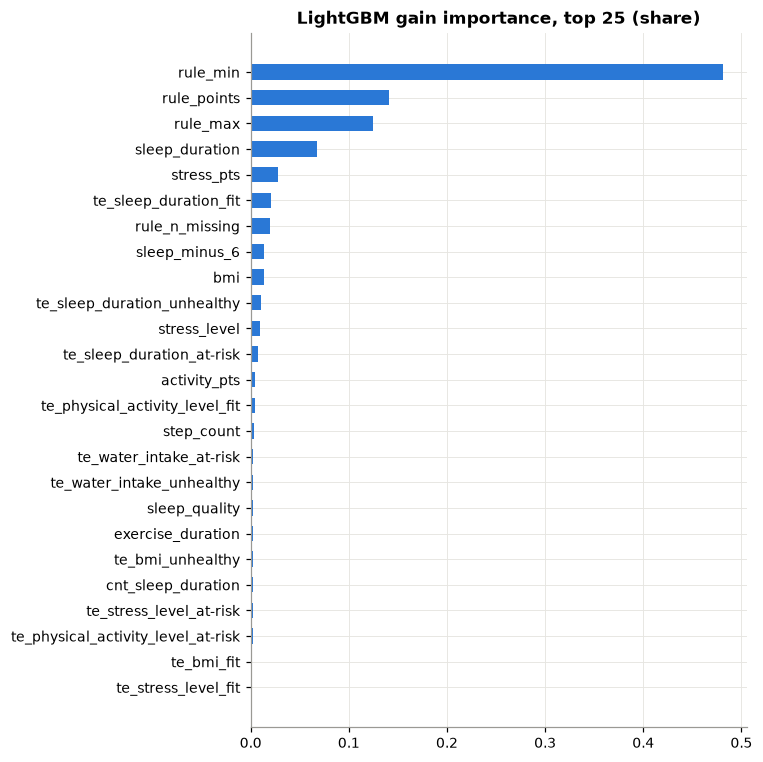

In [11]:
imp = pd.concat(importances, axis=1).mean(axis=1)
imp = (imp / imp.sum()).sort_values().tail(25)
fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(imp.index, imp.values, color=BLUE, height=0.6)
ax.set_title('LightGBM gain importance, top 25 (share)')
plt.tight_layout(); plt.show()

## 6. Submission

In [12]:
sub = sample[['id']].copy()
assert (sub['id'].values == test['id'].values).all()
sub[TARGET] = CLASSES[(blend_test / PRIOR * mult).argmax(1)]
sub.to_csv('submission.csv', index=False)
print(sub.shape)
display(pd.DataFrame({'test predicted': sub[TARGET].value_counts(normalize=True),
                      'OOF predicted': pd.Series(CLASSES[pred_oof]).value_counts(normalize=True),
                      'train actual': train[TARGET].value_counts(normalize=True)}).round(4))

(295753, 2)


,test predicted,OOF predicted,train actual
at-risk,0.8135,0.8119,0.8587
unhealthy,0.1135,0.1140,0.0836
fit,0.0730,0.0741,0.0577


In [13]:
def kaggle_cli(*args):
    # The CLI prints a UTF-8 progress bar; Windows' default cp1252 decoding crashes on it
    return subprocess.run(['kaggle', 'competitions', *args], capture_output=True, text=True,
                          encoding='utf-8', errors='replace')

SUBMIT = True   # set to False to re-run the notebook without submitting again
msg = f'{" + ".join(names)} | prior correction + class multipliers | OOF BA {final_oof_ba:.5f}'
if SUBMIT:
    out = kaggle_cli('submit', COMP, '-f', 'submission.csv', '-m', msg)
    print(out.stdout[-2000:], out.stderr[-300:])

99 submissions remaining today.
Successfully submitted to Predicting Student Health Risk   | 320k/4.49M [00:01<00:09, 445kB/s]
 11%|█▏        | 528k/4.49M [00:01<00:05, 833kB/s]
 19%|█▉        | 896k/4.49M [00:01<00:02, 1.56MB/s]
 37%|███▋      | 1.64M/4.49M [00:01<00:00, 3.17MB/s]
 71%|███████   | 3.17M/4.49M [00:01<00:00, 6.41MB/s]
100%|██████████| 4.49M/4.49M [00:02<00:00, 1.80MB/s]



In [14]:
# Wait for scoring. The competition is closed, so the late submission shows both public and private scores.
for _ in range(30):
    subs = pd.read_csv(io.StringIO(kaggle_cli('submissions', '-c', COMP, '-v').stdout))
    if 'pending' not in str(subs.loc[0, 'status']).lower():
        break
    time.sleep(20)
display(subs.head(3))

,ref,fileName,date,description,status,publicScore,privateScore
0,56967604,submission.csv,2026-10-08 18:56:37.760000,xgb + lgb | prior correction + class multiplie...,SubmissionStatus.COMPLETE,0.94993,0.95049
